# Exploratory Data Analysis: LAI Polymer Drug Release Dataset

This notebook performs exploratory data analysis (EDA) on `Dataset_17_feat.csv`, complementing the modeling workflow in `LAI_drug_release_project_notebook.ipynb`.

It covers a first look at the data, followed by automated profiling reports (ydata-profiling and Sweetviz) to quickly surface distributions, correlations, and data quality issues.

## 1. Install packages

Run this cell in Colab.
If you run locally and already have the packages installed, you can skip it.

In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn statsmodels ydata-profiling[notebook] sweetviz[notebook]


zsh:1: no matches found: ydata-profiling[notebook]


## 2. Imports and general settings

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "eda_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

## 3. Load the dataset

Upload `Dataset_17_feat.csv` to Colab files, or keep it in the same folder as this notebook.

In [3]:
DATA_PATH = "Dataset_17_feat.csv"

# Colab helper: if the file is not present, ask the user to upload it.
# if not os.path.exists(DATA_PATH):
#     try:
#         from google.colab import files
#         print("Dataset_17_feat.csv not found. Please upload it now.")
#         uploaded = files.upload()
#         if "Dataset_17_feat.csv" in uploaded:
#             DATA_PATH = "Dataset_17_feat.csv"
#     except Exception:
#         pass
DATA_PATH = "Dataset_17_feat.csv"
df = pd.read_csv(DATA_PATH)

# Sort by profile and time. This is useful for profile plotting later.
df = df.sort_values(["Experimental_index", "Time"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (3783, 20)


,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
0,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.00,0.04,0.05,0.09,0.00
1,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.17,0.04,0.05,0.09,0.03
2,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,1.03,0.04,0.05,0.09,0.12
3,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,3.26,0.04,0.05,0.09,0.20
4,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,7.04,0.04,0.05,0.09,0.28


Experimental_index      int64
DP_Group               object
LA/GA                 float64
Polymer_MW            float64
CL Ratio              float64
Drug_Tm               float64
Drug_Pka              float64
Initial D/M ratio     float64
DLC                   float64
SA-V                  float64
SE                    float64
Drug_Mw               float64
Drug_TPSA             float64
Drug_NHA              float64
Drug_LogP             float64
Time                  float64
T=0.25                float64
T=0.5                 float64
T=1.0                 float64
Release               float64
dtype: object

## 4. Quick look: last rows of the dataset

In [4]:
df.tail()

,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
3778,181,TAH-PVL-co-PAVL,0.0,32000.0,0.15,295.0,13.63,1.25,0.4,91.19,0.5,532.65,99.13,8.0,4.41,26.0,0.06,0.08,0.12,0.95
3779,181,TAH-PVL-co-PAVL,0.0,32000.0,0.15,295.0,13.63,1.25,0.4,91.19,0.5,532.65,99.13,8.0,4.41,27.0,0.06,0.08,0.12,0.97
3780,181,TAH-PVL-co-PAVL,0.0,32000.0,0.15,295.0,13.63,1.25,0.4,91.19,0.5,532.65,99.13,8.0,4.41,28.0,0.06,0.08,0.12,0.99
3781,181,TAH-PVL-co-PAVL,0.0,32000.0,0.15,295.0,13.63,1.25,0.4,91.19,0.5,532.65,99.13,8.0,4.41,29.0,0.06,0.08,0.12,1.00
3782,181,TAH-PVL-co-PAVL,0.0,32000.0,0.15,295.0,13.63,1.25,0.4,91.19,0.5,532.65,99.13,8.0,4.41,30.0,0.06,0.08,0.12,1.01


## 5. Feature definitions for reproducible EDA

These definitions mirror the original EDA block from `LAI_drug_release_project_notebook.ipynb`. They separate identifiers, the target, early release measurements, and numeric input features before exploratory analysis.

In [5]:
ID_COLS = ["Experimental_index", "DP_Group"]
TARGET = "Release"
EARLY_FEATURES = ["T=0.25", "T=0.5", "T=1.0"]

# All numeric input columns except identifiers and target.
ALL_FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# Zero-shot: no early measured release values.
ZERO_SHOT_FEATURES = [c for c in ALL_FEATURES if c not in EARLY_FEATURES]

# Few-shot: includes early measured release values.
FEW_SHOT_FEATURES = ALL_FEATURES.copy()

print("All features:", ALL_FEATURES)
print()
print("Zero-shot features:", ZERO_SHOT_FEATURES)
print()
print("Few-shot features:", FEW_SHOT_FEATURES)
print()
print("Number of unique release profiles:", df["Experimental_index"].nunique())
print("Number of unique drug-polymer groups:", df["DP_Group"].nunique())


All features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Zero-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time']

Few-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Number of unique release profiles: 181
Number of unique drug-polymer groups: 34


## 6. Basic EDA reproduced in Python

This section is the EDA exploration that was previously in the main LAI modeling notebook. It checks missing values, summary statistics, target distribution, and Spearman correlation structure, and writes reusable outputs to `eda_outputs/`.

In [6]:
# Missing values
missing_table = df.isna().sum().to_frame("missing_count")
missing_table["missing_percent"] = 100 * missing_table["missing_count"] / len(df)
display(missing_table)

# Basic statistics
display(df.describe())

missing_table.to_csv(os.path.join(OUTPUT_DIR, "missing_values.csv"))
df.describe().to_csv(os.path.join(OUTPUT_DIR, "summary_statistics.csv"))

,missing_count,missing_percent
Experimental_index,0,0.0
DP_Group,0,0.0
LA/GA,0,0.0
Polymer_MW,0,0.0
CL Ratio,0,0.0
Drug_Tm,0,0.0
Drug_Pka,0,0.0
Initial D/M ratio,0,0.0
DLC,0,0.0
SA-V,0,0.0


,Experimental_index,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
count,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000
mean,109.012688,0.804766,35788.243458,0.062950,212.501586,10.706394,0.705757,0.185916,696.890563,0.292556,568.665617,143.050444,9.970130,2.908639,25.282112,0.051065,0.085284,0.136479,0.464859
std,52.938740,1.014624,24367.696754,0.067476,66.170200,2.532575,0.626395,0.129409,2298.216607,0.261045,279.755827,85.883087,5.494135,1.535961,33.393548,0.053009,0.081625,0.125617,0.328807
min,1.000000,0.000000,8300.000000,0.000000,66.000000,4.400000,0.010000,0.000000,2.480000,0.000000,130.080000,23.470000,2.000000,-2.210000,0.000000,0.000000,0.000000,0.010000,0.000000
25%,66.000000,0.000000,15000.000000,0.000000,206.000000,10.360000,0.115000,0.060000,2.890000,0.000000,331.350000,78.290000,6.000000,2.420000,3.285000,0.010000,0.020000,0.040000,0.140000
50%,124.000000,1.000000,32000.000000,0.040000,216.500000,10.360000,0.830000,0.180000,65.930000,0.500000,434.500000,99.600000,8.000000,3.740000,14.000000,0.040000,0.070000,0.110000,0.480000
75%,154.000000,1.000000,44000.000000,0.150000,262.000000,11.750000,1.000000,0.310000,155.560000,0.500000,853.920000,221.290000,15.000000,3.740000,32.000000,0.070000,0.120000,0.180000,0.770000
max,181.000000,3.000000,108000.000000,0.180000,312.500000,19.690000,2.500000,0.620000,22018.350000,1.000000,1269.470000,466.340000,30.000000,5.850000,190.000000,0.310000,0.490000,0.720000,1.070000


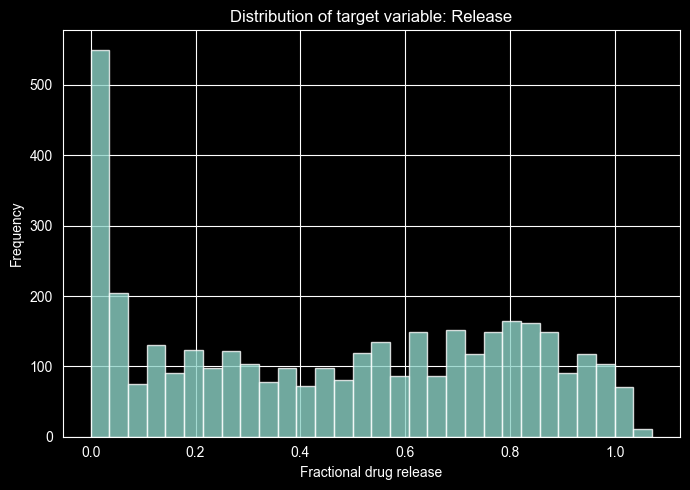

In [7]:
plt.figure(figsize=(7, 5))
plt.hist(df[TARGET], bins=30, alpha=0.8)
plt.xlabel("Fractional drug release")
plt.ylabel("Frequency")
plt.title("Distribution of target variable: Release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_distribution.png"), dpi=300)
plt.show()

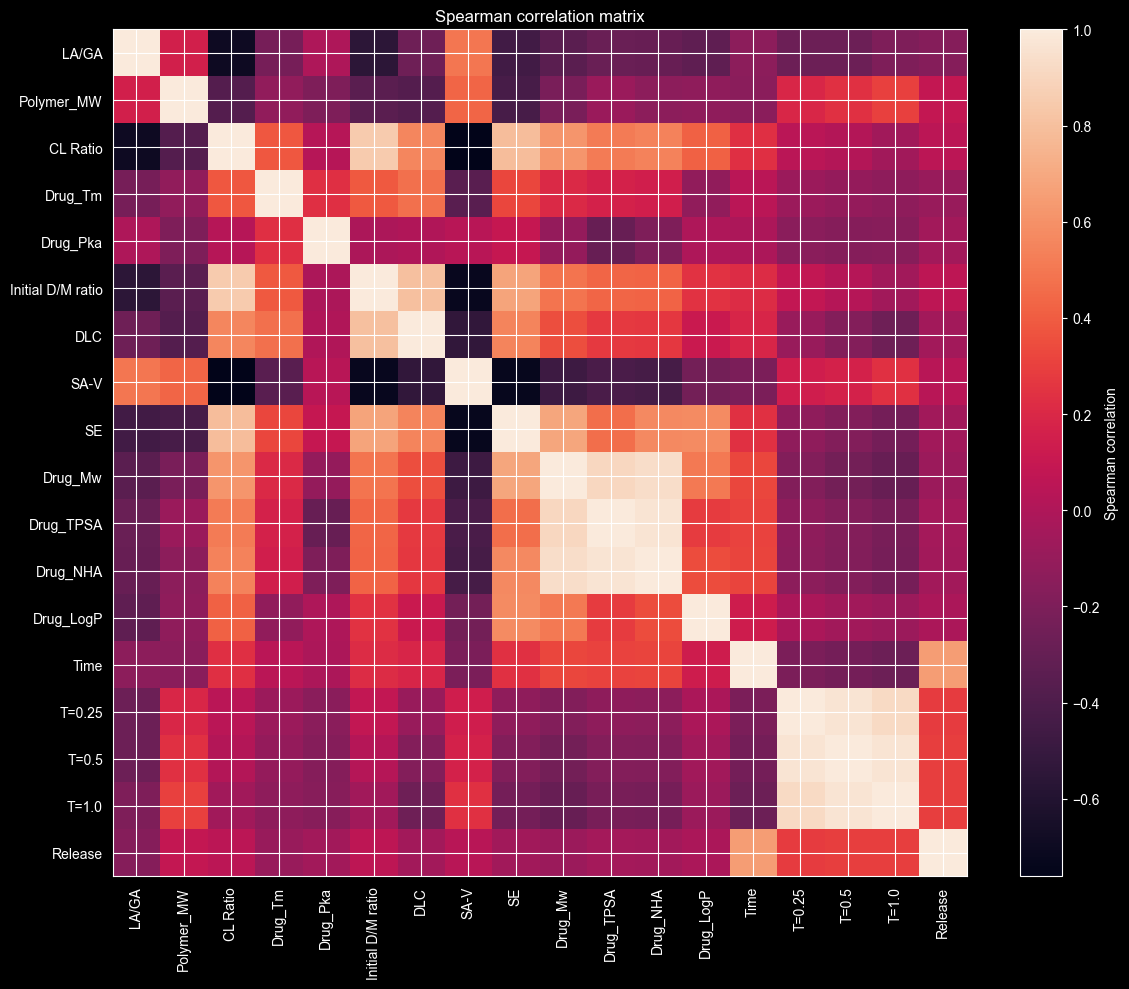

In [8]:
# Correlation matrix for numeric features and target
corr_cols = ALL_FEATURES + [TARGET]
corr = df[corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label="Spearman correlation")
plt.title("Spearman correlation matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.png"), dpi=300)
plt.show()

corr.to_csv(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.csv"))

### EDA paper note

Exploratory analysis was repeated in Python to make the workflow reproducible. Missing values, descriptive statistics, target distribution, and correlation structure were examined before model training. This step complements the automated profiling reports generated later in this notebook.

## 7. Optional VIF analysis for the linear baseline

VIF is mainly useful for linear models. Tree-based models can handle correlated features better, but VIF is still useful as a connection to the original Orange/linear-model exploration.

In [9]:
# Optional VIF function.
# statsmodels may not be installed in every environment, so install if needed.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import shutil
    import subprocess
    import sys
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--python", sys.executable, "-q", "statsmodels"])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe, features):
    X_vif = dataframe[features].copy()
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

    # VIF requires numeric features and no constant duplicate problems.
    X_values = X_vif.values

    rows = []
    for i, col in enumerate(features):
        try:
            vif_value = variance_inflation_factor(X_values, i)
        except Exception:
            vif_value = np.nan
        rows.append({"Feature": col, "VIF": vif_value})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table = calculate_vif(df, ALL_FEATURES)
display(vif_table)

vif_table.to_csv(os.path.join(OUTPUT_DIR, "vif_all_features.csv"), index=False)

,Feature,VIF
9,Drug_Mw,565.959213
11,Drug_NHA,402.248273
10,Drug_TPSA,400.199306
15,T=0.5,111.838240
16,T=1.0,50.646403
14,T=0.25,39.919470
12,Drug_LogP,33.268305
4,Drug_Pka,18.536084
3,Drug_Tm,18.340037
5,Initial D/M ratio,12.827757


In [10]:
def iterative_vif_selection(dataframe, features, threshold=5.0):
    selected = features.copy()
    history = []

    while True:
        vif_table = calculate_vif(dataframe, selected)
        max_vif = vif_table["VIF"].max()

        if pd.isna(max_vif) or max_vif <= threshold:
            break

        remove_feature = vif_table.iloc[0]["Feature"]
        history.append({
            "removed_feature": remove_feature,
            "max_vif": max_vif,
            "remaining_features": len(selected) - 1
        })
        selected.remove(remove_feature)

    final_vif = calculate_vif(dataframe, selected)
    return selected, pd.DataFrame(history), final_vif

vif_selected_features, vif_history, final_vif = iterative_vif_selection(df, ALL_FEATURES, threshold=5.0)

print("Selected features after iterative VIF:")
print(vif_selected_features)

display(vif_history)
display(final_vif)

vif_history.to_csv(os.path.join(OUTPUT_DIR, "vif_elimination_history.csv"), index=False)
final_vif.to_csv(os.path.join(OUTPUT_DIR, "vif_selected_features.csv"), index=False)

Selected features after iterative VIF:
['LA/GA', 'Polymer_MW', 'DLC', 'SA-V', 'Drug_TPSA', 'Drug_LogP', 'Time', 'T=0.25']


,removed_feature,max_vif,remaining_features
0,Drug_Mw,565.959213,16
1,Drug_NHA,344.736909,15
2,T=0.5,94.424485,14
3,T=1.0,17.697707,13
4,Drug_Tm,15.364699,12
5,Initial D/M ratio,12.183919,11
6,Drug_Pka,8.446216,10
7,CL Ratio,6.946450,9
8,SE,5.063465,8


,Feature,VIF
4,Drug_TPSA,4.031936
2,DLC,3.702584
5,Drug_LogP,3.376416
1,Polymer_MW,3.329146
7,T=0.25,1.936235
6,Time,1.925993
0,LA/GA,1.770712
3,SA-V,1.607809


### VIF paper note

VIF analysis was used only to support the interpretation of linear models. After iterative elimination of highly collinear predictors, a reduced feature set can be used for Ridge/MLR-style baselines, while nonlinear tree-based models can still be trained on the full descriptor set.

## 8. Automated profiling report (ydata-profiling)

Generates a full HTML profiling report (distributions, correlations, missing values, alerts) and saves it to `OUTPUT_DIR`.

In [11]:
import ydata_profiling as yp

profiling_output_file = os.path.join(OUTPUT_DIR, "eda_profiling.html")

report = yp.ProfileReport(df, title="LAI EDA", explorative=True)
report.to_file(profiling_output_file)
print(f"Report written to: {profiling_output_file}")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:00<00:00, 160087.94it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Report written to: eda_outputs/eda_profiling.html


## 9. Automated profiling report (Sweetviz)

Generates a target-aware HTML report comparing feature distributions against `Release`, and saves it to `OUTPUT_DIR`.

                                             |          | [  0%]   00:00 -> (? left)

AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'

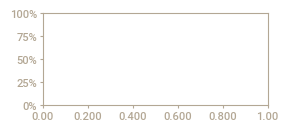

In [12]:
import sweetviz as sv

sweetviz_output_file = os.path.join(OUTPUT_DIR, "sweetviz_report.html")

sweetviz_report = sv.analyze(df, target_feat="Release")
sweetviz_report.show_html(filepath=sweetviz_output_file, open_browser=False)
print(f"Sweetviz report written to: {sweetviz_output_file}")